# Part E: Naive Bayes Classifier & Probability

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_excel(
    "Message_Intelligence_Dataset_5200.xlsx"
)

print(df.shape)

df.head()

(5200, 16)


,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [3]:
target_col = "spam_label"

drop_cols = []

for col in [
    'message_id',
    'message_text',
    'timestamp'
]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(
    columns=[target_col] + drop_cols
)

y = df[target_col]

In [4]:
imputer = SimpleImputer(
    strategy='median'
)

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print(
    X.isnull().sum()
)

message_length             0
word_count                 0
num_urls                   0
num_digits                 0
num_special_chars          0
spam_keyword_score         0
legit_keyword_score        0
sender_activity_score      0
sender_account_age_days    0
messages_sent_last_24h     0
hour_of_day                0
day_of_week                0
dtype: int64


In [5]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4160, 12)
(1040, 12)


In [7]:
nb = GaussianNB()

nb.fit(
    X_train,
    y_train
)

y_pred = nb.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Naive Bayes Accuracy:",
    accuracy
)

Naive Bayes Accuracy: 1.0


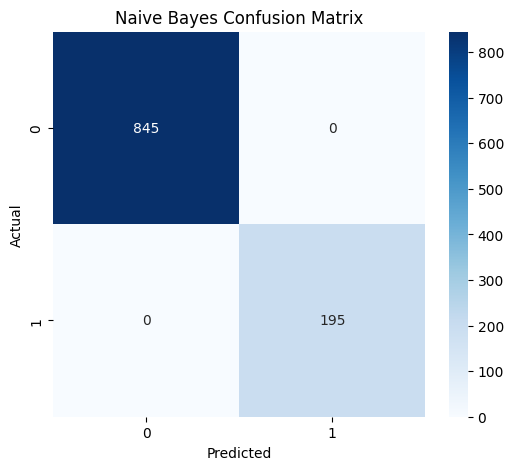

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Naive Bayes Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [9]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



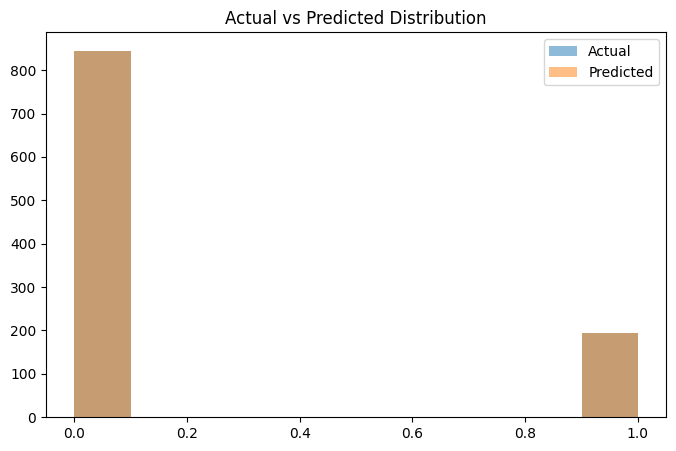

In [10]:
plt.figure(figsize=(8,5))

plt.hist(
    y_test,
    alpha=0.5,
    label='Actual'
)

plt.hist(
    y_pred,
    alpha=0.5,
    label='Predicted'
)

plt.legend()

plt.title(
    "Actual vs Predicted Distribution"
)

plt.show()

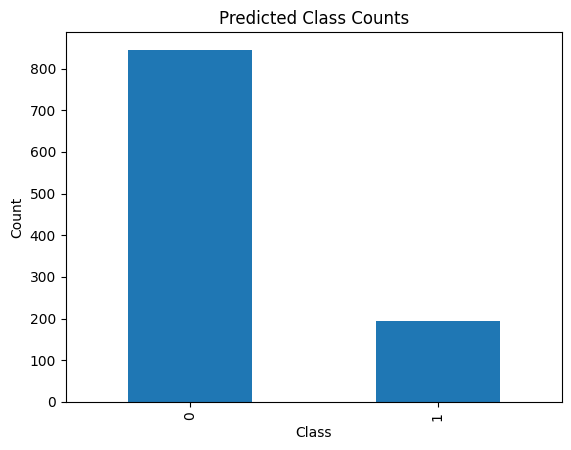

In [11]:
pd.Series(
    y_pred
).value_counts().plot(
    kind='bar'
)

plt.title(
    "Predicted Class Counts"
)

plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [12]:
probabilities = nb.predict_proba(
    X_test
)

prob_df = pd.DataFrame(
    probabilities,
    columns=[
        "Legitimate_Prob",
        "Spam_Prob"
    ]
)

print(
    prob_df.head(10)
)

   Legitimate_Prob     Spam_Prob
0              1.0  0.000000e+00
1              0.0  1.000000e+00
2              1.0  0.000000e+00
3              1.0  0.000000e+00
4              1.0  0.000000e+00
5              1.0  0.000000e+00
6              1.0  4.313753e-28
7              1.0  0.000000e+00
8              1.0  0.000000e+00
9              1.0  0.000000e+00


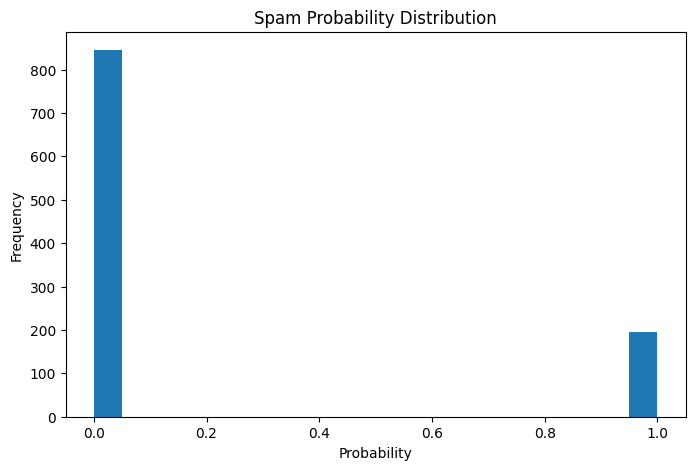

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    prob_df["Spam_Prob"],
    bins=20
)

plt.title(
    "Spam Probability Distribution"
)

plt.xlabel(
    "Probability"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [14]:
sample = X_test[0].reshape(1,-1)

print(
    "Predicted Class:",
    nb.predict(sample)
)

print(
    "Class Probabilities:"
)

print(
    nb.predict_proba(sample)
)

Predicted Class: [0]
Class Probabilities:
[[1. 0.]]


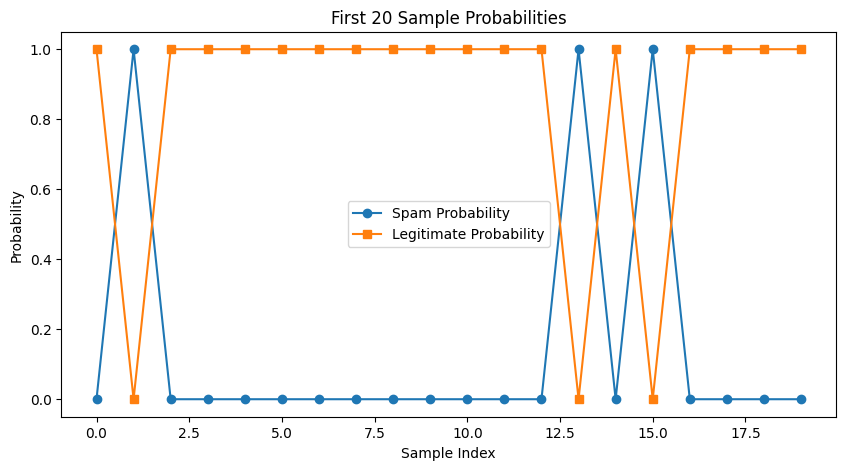

In [15]:
sample_probs = prob_df.head(20)

plt.figure(figsize=(10,5))

plt.plot(
    sample_probs["Spam_Prob"],
    marker='o',
    label='Spam Probability'
)

plt.plot(
    sample_probs["Legitimate_Prob"],
    marker='s',
    label='Legitimate Probability'
)

plt.legend()

plt.title(
    "First 20 Sample Probabilities"
)

plt.xlabel(
    "Sample Index"
)

plt.ylabel(
    "Probability"
)

plt.show()

In [16]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Spam_Probability": prob_df["Spam_Prob"]
})

comparison.head(20)

,Actual,Predicted,Spam_Probability
0,0,0,0.000000e+00
1,1,1,1.000000e+00
2,0,0,0.000000e+00
3,0,0,0.000000e+00
4,0,0,0.000000e+00
5,0,0,0.000000e+00
6,0,0,4.313753e-28
7,0,0,0.000000e+00
8,0,0,0.000000e+00
9,0,0,0.000000e+00


In [17]:
misclassified = np.sum(
    y_test != y_pred
)

correct = len(y_test) - misclassified

print(
    "Misclassified Samples:",
    misclassified
)

Misclassified Samples: 0


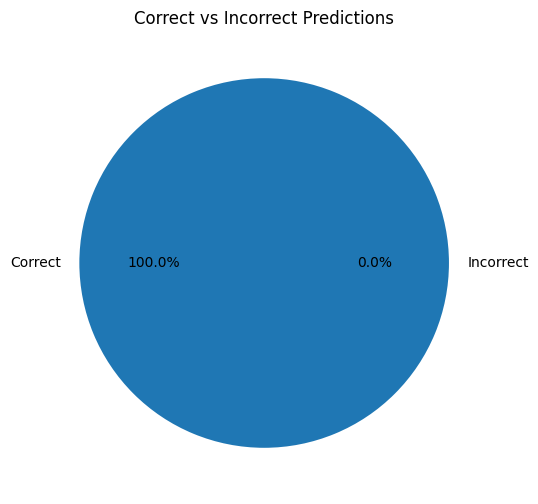

In [18]:
plt.figure(figsize=(6,6))

plt.pie(
    [correct, misclassified],
    labels=[
        "Correct",
        "Incorrect"
    ],
    autopct="%1.1f%%"
)

plt.title(
    "Correct vs Incorrect Predictions"
)

plt.show()

 ## Task 17: Manual Conditional Probability (Theory)
 
Conditional Probability:

Example:

A = Message is Spam

B = Message contains suspicious features

This calculates the probability that a message is spam given observed features.
 
 ______


## Task 18: Bayes' Theorem
Where:

P(A) = Prior Probability

P(B|A) = Likelihood

P(B) = Evidence

P(A|B) = Posterior Probability

_____


## Task 19: Comparison of Theory vs Model

The Naive Bayes classifier computes posterior probabilities using Bayes' Theorem.

The class with the highest probability is selected as the prediction.

The probability values generated by predict_proba() match the theoretical Bayesian approach.

Therefore, the model predictions are directly based on probability calculations.

_____

## Conclusion

The Gaussian Naive Bayes classifier was successfully implemented for spam message classification. The model estimated class probabilities using Bayes' Theorem and predicted the class with the highest posterior probability. Probability distributions, confusion matrix analysis, and prediction comparisons demonstrated how theoretical probability concepts are applied in practice. Although Naive Bayes assumes feature independence, it provided fast and effective classification performance for the spam detection problem.

